## Question 2 (Coding: Verifying the Spectral Decomposition- 25 pts). The spectral decomposition theo
rem states that a symmetric matrix can be reconstructed from the sum of its eigenvalue-weighted outer
products: A = p
i=1 iqiq↓
i . You will verify this computationally.

In [1]:
# (a) Create a random 5→5 symmetric matrix in Python.
import numpy as np

random_matrix = np.random.randn(5, 5)

random_symmetric_matrix = (random_matrix + random_matrix.T) / 2


In [2]:
# (b) Use ‘np.linalg.eig‘ to find its eigenvalues (‘lambda_i‘) and eigenvectors (‘q_i‘)

eigenvalues, eigenvectors = np.linalg.eig(random_symmetric_matrix)

In [13]:
""" (c) Write a ‘for‘ loop that iterates from i = 1 to p. In each iteration, compute the rank-1 outer product
matrix qiq↓
i (in NumPy, this can be done with ‘np.outer(q_i, q_i)‘) and multiply it by its eigenvalue
i
. Sum these matrices together
"""

result_matrix = np.zeros((5, 5))
for idx in range(1, 6):
    eigenvalue = eigenvalues[idx -1]
    eigenvector = eigenvectors[:, idx -1]

    outer_product = eigenvalue * np.outer(eigenvector, eigenvector)
    result_matrix += outer_product

print(result_matrix)
print(random_symmetric_matrix)

[[-0.60730461 -0.49562016  0.73715148  0.09539189  0.45041774]
 [-0.49562016 -0.19731092  1.26941368  0.79944605  0.64680409]
 [ 0.73715148  1.26941368 -0.45048163  0.59078315  0.08801111]
 [ 0.09539189  0.79944605  0.59078315  2.06521178  0.67436564]
 [ 0.45041774  0.64680409  0.08801111  0.67436564 -0.1095608 ]]
[[-0.60730461 -0.49562016  0.73715148  0.09539189  0.45041774]
 [-0.49562016 -0.19731092  1.26941368  0.79944605  0.64680409]
 [ 0.73715148  1.26941368 -0.45048163  0.59078315  0.08801111]
 [ 0.09539189  0.79944605  0.59078315  2.06521178  0.67436564]
 [ 0.45041774  0.64680409  0.08801111  0.67436564 -0.1095608 ]]


In [14]:
"""
(d) Compare your reconstructed matrix to the original matrix A using ‘np.allclose()‘. Confirm that the
reconstruction is accurate.
"""
print(np.allclose(result_matrix, random_symmetric_matrix))

True


Question 3 (Coding: Scaling of Eigendecomposition- 30 pts). You will now empirically test the O(p3)
complexity of eigendecomposition for dense symmetric matrices.

 Write a Python script that loops through matrix sizes p ↔{100,200,400,800,1600,3200}.
(b) Inside the loop, generate a random p→ p symmetric matrix.
(c) Use the ‘time‘ module to measure the execution time of ‘np.linalg.eig()‘ for each matrix.
(d) Plot the execution time versus matrix size on a linear-linear scale.
(e) Fit a line to your linear-linear data points and report the slope. Does the empirical complexity match
the theoretical O(p3) complexity?

In [18]:
import time
sizes = np.array([100, 200, 400, 800, 1600, 3200])
times = []

for p in matrix_sizes:
    random_matrix = np.random.randn(p, p)
    random_symmetric_matrix = (random_matrix + random_matrix.T) / 2

    start = time.perf_counter()
    eigenvalues, eigenvectors = np.linalg.eig(random_symmetric_matrix)
    end = time.perf_counter()
    times.append(end-start)



Plot saved as 'eig_scaling.png'


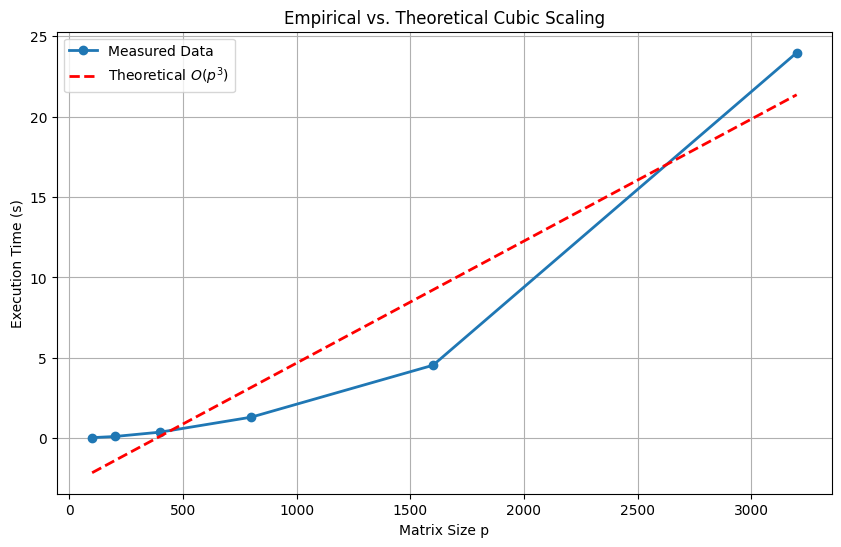

In [21]:
import matplotlib.pyplot as plt


linear_model = np.poly1d(np.polyfit(sizes, times, 1))
scaled_theoretical = [linear_model(p) for p in sizes]

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, 'o-', linewidth=2, label='Measured Data')
plt.plot(sizes, scaled_theoretical, 'r--', linewidth=2, label=f'Theoretical $O(p^3)$')

plt.xlabel("Matrix Size p")
plt.ylabel("Execution Time (s)")
plt.title("Empirical vs. Theoretical Cubic Scaling")
plt.legend()
plt.grid(True)
plt.savefig('eig_scaling.png', bbox_inches='tight')
print("Plot saved as 'eig_scaling.png'")
plt.show()

Question 4 (Coding: PCA for Image Compression- 30 pts). In this problem, you will use your ‘pca‘
function from the programming chapter (or implement a simplified version) to perform dimensionality
reduction on a single image, demonstrating its use for compression.

In [ ]:
# (a) Load a standard grayscale image and convert it to a NumPy array
from skimage import data, color

image = data.camera() 
X = image.astype(float)
n, p = X.shape
print(image)

[[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]
512 512


In [29]:
# (b) Treat the rows of the image as data points. Apply PCA to this matrix

Centered_X = X - np.mean(X, axis = 0)
Scaled_X = Centered_X / np.std(X, axis = 0)

covariance_matrix = (Scaled_X.T @ Scaled_X) / (n - 1)

eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)


sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

Projected_X = Scaled_X @ eigenvectors

Plot saved as pca_compression.png


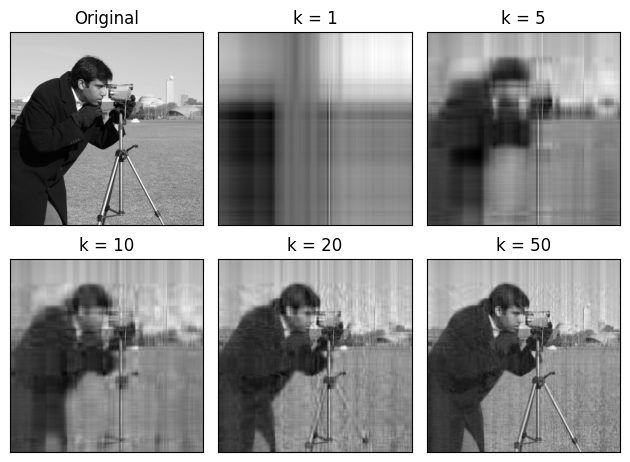

In [31]:
""" 
Reconstruct the image using only the top k principal components for different values of k (e.g.,
k =1,5,10,20,50). The reconstruction is given by Xrecon =(XcQk)Q↓
k + µ, where Xc is the centered
image data, Qk are the top k components, and µ is the mean row.
"""
means = np.mean(X, axis = 0)
k_values = [1, 5, 10, 20, 50]
reconstructions = [(Centered_X @ eigenvectors[:, :k_val])@ eigenvectors[:, :k_val].T + means for k_val in k_values ]

plt.subplot(2, 3, 1)
plt.imshow(X, cmap='gray')
plt.title("Original")
plt.xticks([]); plt.yticks([])

for i, k in enumerate(k_values):

    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructions[i], cmap='gray')
    plt.title(f"k = {k}")
    plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.savefig('pca_compression.png', bbox_inches='tight')
print('Plot saved as pca_compression.png')
plt.show()


In [33]:
total_variance = np.sum(eigenvalues ** 2)
for k in k_values:
    explained = np.sum(eigenvalues[:k] ** 2) / total_variance * 100
    print(f"k={k:3d}: {explained:.2f}% variance explained")

k=  1: 86.30% variance explained
k=  5: 99.67% variance explained
k= 10: 99.88% variance explained
k= 20: 99.96% variance explained
k= 50: 99.99% variance explained
